In [32]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')



In [33]:
# Load the dataset
df = pd.read_csv("content_clean_for_analysis.csv")
df.head()

,content_hash_id,client_hash_id,first_seen,last_seen,active_days,total_impressions,total_clicks,ctr,avg_position,total_pageviews,...,copilot_share,claude_share,meta_share,has_search,has_engagement,has_ai,is_active,engagement_tier,search_tier,activity_tier
0,content_1a6296faee432dae,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,Low,Low,High
1,content_dc34c661d63e55a9,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,Low,Low,High
2,content_dcbfbaf912c88c76,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,Low,Low,High
3,content_44de3cf116b9e3f1,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,Low,Low,High
4,content_c3283758d93f34fd,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,Low,Low,High


In [34]:
# Shape of the dataset

df.shape


(409205, 44)

In [35]:
# Check for column info and dtypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409205 entries, 0 to 409204
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   content_hash_id       409205 non-null  object 
 1   client_hash_id        409205 non-null  object 
 2   first_seen            409205 non-null  object 
 3   last_seen             409205 non-null  object 
 4   active_days           409205 non-null  int64  
 5   total_impressions     409205 non-null  float64
 6   total_clicks          409205 non-null  float64
 7   ctr                   409205 non-null  float64
 8   avg_position          409205 non-null  float64
 9   total_pageviews       328450 non-null  float64
 10  total_engagement_sec  328450 non-null  float64
 11  engagement_per_view   409205 non-null  float64
 12  total_scrolls         328450 non-null  float64
 13  scrolls_per_view      409205 non-null  float64
 14  total_users           328450 non-null  float64
 15  

In [36]:
df.isnull().sum()

,0
content_hash_id,0
client_hash_id,0
first_seen,0
last_seen,0
active_days,0
total_impressions,0
total_clicks,0
ctr,0
avg_position,0
total_pageviews,80755


In [37]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [38]:
# Statistical distribution

df.describe().T

,count,mean,std,min,25%,50%,75%,max
active_days,409205.0,28.561924,3.829242,3.0,30.0,30.0,30.000000,30.0
total_impressions,409205.0,528.329009,3698.473081,0.0,0.0,1.0,98.000000,615012.0
total_clicks,409205.0,2.954795,326.984994,0.0,0.0,0.0,0.000000,152170.0
ctr,409205.0,0.003590,0.023825,0.0,0.0,0.0,0.000000,1.0
avg_position,409205.0,180.454705,1137.201182,0.0,0.0,0.0,64.066667,365196.2
total_pageviews,328450.0,14.800113,1764.961078,0.0,0.0,0.0,2.000000,704238.0
total_engagement_sec,328450.0,33.604171,596.912204,0.0,0.0,0.0,0.000000,79598.0
engagement_per_view,409205.0,1.315035,13.659493,0.0,0.0,0.0,0.000000,1416.0
total_scrolls,328450.0,1.148074,73.912996,0.0,0.0,0.0,0.000000,27649.0
scrolls_per_view,409205.0,0.050059,0.186407,0.0,0.0,0.0,0.000000,4.0


In [39]:
# For objects

df.describe(include=object).T

,count,unique,top,freq
content_hash_id,409205,409205,content_e48878c306788abe,1
client_hash_id,409205,65,client_3ffa76342f366962,32647
first_seen,409205,28,2026-06-01,390720
last_seen,409205,6,2026-06-30,339652
engagement_tier,409205,4,Low,409174
search_tier,409205,3,Low,409183
activity_tier,409205,4,High,395197


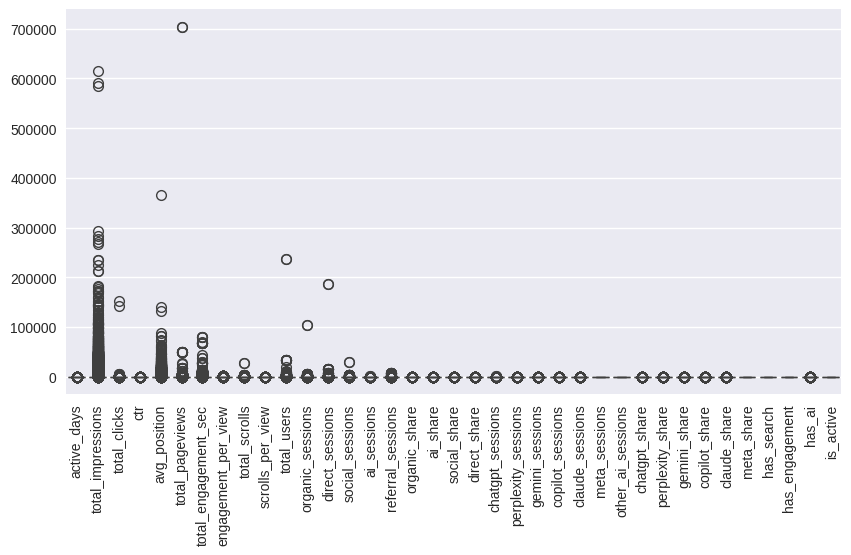

In [40]:
# Outliers
plt.figure(figsize=(10,5))
sns.boxplot(data  = df)
plt.xticks(rotation=90)
plt.show()


# **Data Cleaning**

In [41]:
# Define columns to drop
columns_to_drop = [
    # Share columns (derived from raw metrics)
    'organic_share',
    'ai_share',
    'social_share',
    'direct_share',

    # AI channel shares (derived from raw sessions)
    'chatgpt_share',
    'perplexity_share',
    'gemini_share',
    'copilot_share',
    'claude_share',
    'meta_share',

    # Tiers (categorical bins of continuous variables)
    'engagement_tier',
    'search_tier',
    'activity_tier',
]

# Drop columns that exist
existing_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drop)

In [42]:
# Eliminate missing values

df.dropna(inplace=True)

In [43]:
# Confirm

df.isnull().sum()

,0
content_hash_id,0
client_hash_id,0
first_seen,0
last_seen,0
active_days,0
total_impressions,0
total_clicks,0
ctr,0
avg_position,0
total_pageviews,0


In [44]:
# confirming shape and info of the new dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 328450 entries, 0 to 409204
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   content_hash_id       328450 non-null  object 
 1   client_hash_id        328450 non-null  object 
 2   first_seen            328450 non-null  object 
 3   last_seen             328450 non-null  object 
 4   active_days           328450 non-null  int64  
 5   total_impressions     328450 non-null  float64
 6   total_clicks          328450 non-null  float64
 7   ctr                   328450 non-null  float64
 8   avg_position          328450 non-null  float64
 9   total_pageviews       328450 non-null  float64
 10  total_engagement_sec  328450 non-null  float64
 11  engagement_per_view   328450 non-null  float64
 12  total_scrolls         328450 non-null  float64
 13  scrolls_per_view      328450 non-null  float64
 14  total_users           328450 non-null  float64
 15  organ

In [45]:
# save the cleaned dataset
df.to_csv("final_cleaned_content_dataset.csv", index = False)

In [45]:
from google.colab import files

# Download the file directly
files.download('final_cleaned_content_dataset.csv')

In [46]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy your file to Google Drive
!cp final_cleaned_content_dataset.csv /content/drive/MyDrive/

Mounted at /content/drive
